In [25]:
import sklearn
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score

In [4]:
ls

Untitled.ipynb       aligned_linkage.npy  kmeans.pkl


In [15]:
cluster_distances = np.load("aligned_linkage.npy")
clusters = np.argmin(cluster_distances, axis=-1)
unique, counts = np.unique(clusters, return_counts=True)
clusters_count = dict(zip(unique, counts))

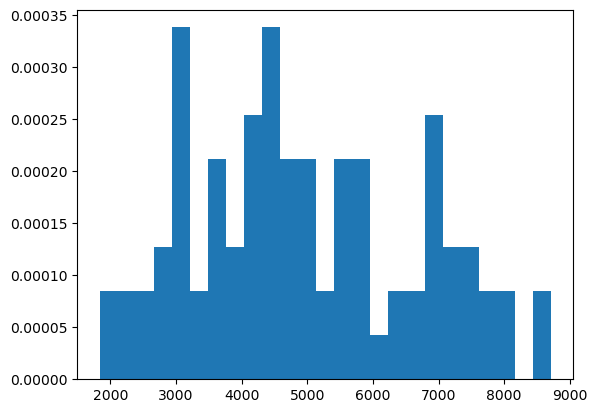

In [22]:
plt.hist(counts, density=True, bins=25)
plt.show()

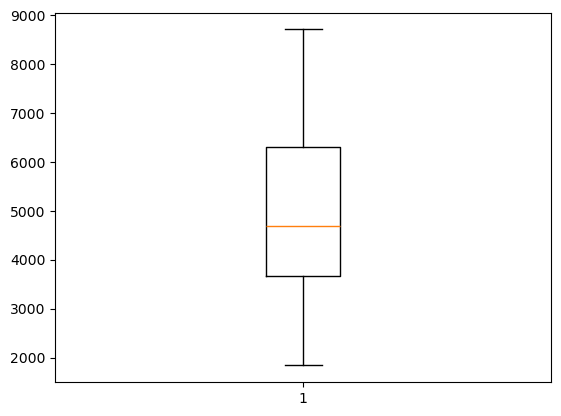

In [24]:
plt.boxplot(counts)
plt.show()

In [27]:
with open("kmeans.pkl", "rb") as f:
    kmeans = pkl.load(f)

/Users/gabdu45/opt/miniconda3/envs/mdanalysis/lib/python3.14/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [36]:
sorted(clusters_count)

[np.int64(0),
 np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(4),
 np.int64(5),
 np.int64(6),
 np.int64(7),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(12),
 np.int64(13),
 np.int64(14),
 np.int64(15),
 np.int64(16),
 np.int64(17),
 np.int64(18),
 np.int64(19),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(23),
 np.int64(24),
 np.int64(25),
 np.int64(26),
 np.int64(27),
 np.int64(28),
 np.int64(29),
 np.int64(30),
 np.int64(31),
 np.int64(32),
 np.int64(33),
 np.int64(34),
 np.int64(35),
 np.int64(36),
 np.int64(37),
 np.int64(38),
 np.int64(39),
 np.int64(40),
 np.int64(41),
 np.int64(42),
 np.int64(43),
 np.int64(44),
 np.int64(45),
 np.int64(46),
 np.int64(47),
 np.int64(48),
 np.int64(49),
 np.int64(50),
 np.int64(51),
 np.int64(52),
 np.int64(53),
 np.int64(54),
 np.int64(55),
 np.int64(56),
 np.int64(57),
 np.int64(58),
 np.int64(59),
 np.int64(60),
 np.int64(61),
 np.int64(62),
 np.int64(63),
 np.int64(64),
 np.int64(65),
 np.int64(66),
 np.i

In [35]:
np.array(list(zip(clusters, np.array(range(426066))))))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [37]:
clusters_count

{np.int64(0): np.int64(4777),
 np.int64(1): np.int64(5549),
 np.int64(2): np.int64(5592),
 np.int64(3): np.int64(7093),
 np.int64(4): np.int64(3963),
 np.int64(5): np.int64(3009),
 np.int64(6): np.int64(5935),
 np.int64(7): np.int64(3244),
 np.int64(8): np.int64(6225),
 np.int64(9): np.int64(4700),
 np.int64(10): np.int64(7945),
 np.int64(11): np.int64(2271),
 np.int64(12): np.int64(4273),
 np.int64(13): np.int64(2578),
 np.int64(14): np.int64(4086),
 np.int64(15): np.int64(6810),
 np.int64(16): np.int64(7529),
 np.int64(17): np.int64(4090),
 np.int64(18): np.int64(3716),
 np.int64(19): np.int64(5757),
 np.int64(20): np.int64(6892),
 np.int64(21): np.int64(3122),
 np.int64(22): np.int64(3083),
 np.int64(23): np.int64(2686),
 np.int64(24): np.int64(6974),
 np.int64(25): np.int64(4530),
 np.int64(26): np.int64(7712),
 np.int64(27): np.int64(4262),
 np.int64(28): np.int64(3049),
 np.int64(29): np.int64(4656),
 np.int64(30): np.int64(4423),
 np.int64(31): np.int64(2907),
 np.int64(32): np.

In [39]:
np.array(range(426066))[clusters == 85]

array([    36,     56,     97, ..., 425635, 425827, 425978], shape=(7568,))

In [51]:
distances_per_clusters = {}
all_avg = []
all_median = []
all_std = []
for i in range(86):
    dist = cluster_distances[np.array(range(426066))[clusters == i]]
    distances_per_clusters.update({i:{"dist":dist, "mean":np.mean(dist), "median":np.median(dist), "std":np.std(dist)}})
    all_avg.append(np.mean(dist))
    all_median.append(np.median(dist))
    all_std.append(np.std(dist))
    

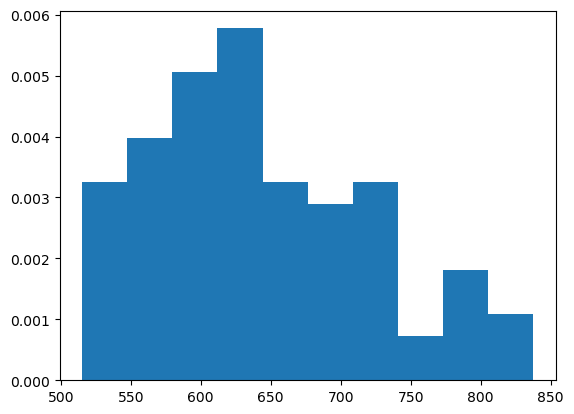

In [54]:
plt.hist(all_avg, density=True)
plt.show()

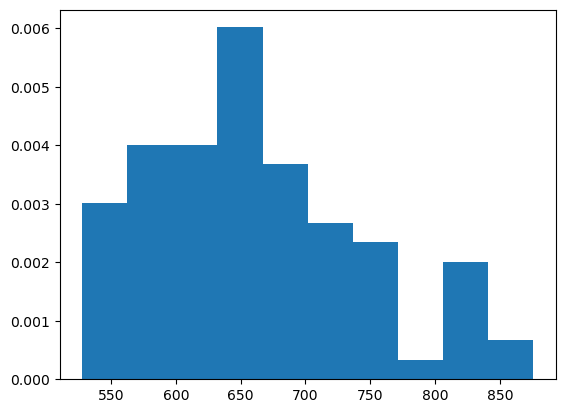

In [55]:
plt.hist(all_median, density=True)
plt.show()

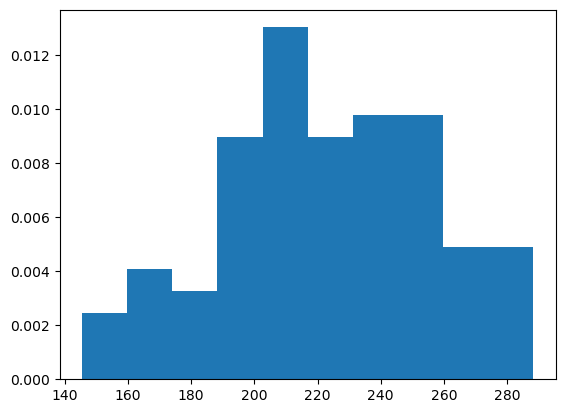

In [56]:
plt.hist(all_std, density=True)
plt.show()

In [58]:
kmeans.cluster_centers_

(86, 5037)

In [63]:
between_cluster_distances = sklearn.metrics.pairwise_distances(kmeans.cluster_centers_)

(array([  86.,  462.,  672., 1064., 1508., 1600., 1086.,  616.,  242.,
          60.]),
 array([   0.        ,  130.46020508,  260.92041016,  391.38061523,
         521.84082031,  652.30102539,  782.76123047,  913.22143555,
        1043.68164062, 1174.1418457 , 1304.60205078]),
 <BarContainer object of 10 artists>)

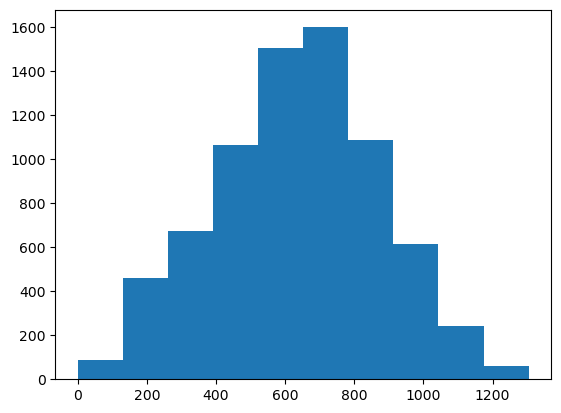

In [66]:
plt.hist(between_cluster_distances.flatten())

In [83]:
all_inertia = []
for i in range(20, 176):
    with open(f"cluster_85/multiple_kmeans/kmeans_{i}.pkl", "rb") as f:
        km = pkl.load(f)
        all_inertia.append(np.sqrt(km.inertia_))

FileNotFoundError: [Errno 2] No such file or directory: 'cluster_85/multiple_kmeans/kmeans_20.pkl'

In [81]:
ls  cluster_85/multiple_kmeans/

kmeans_100.pkl  kmeans_120.pkl  kmeans_140.pkl  kmeans_160.pkl  kmeans_81.pkl
kmeans_101.pkl  kmeans_121.pkl  kmeans_141.pkl  kmeans_161.pkl  kmeans_82.pkl
kmeans_102.pkl  kmeans_122.pkl  kmeans_142.pkl  kmeans_162.pkl  kmeans_83.pkl
kmeans_103.pkl  kmeans_123.pkl  kmeans_143.pkl  kmeans_163.pkl  kmeans_84.pkl
kmeans_104.pkl  kmeans_124.pkl  kmeans_144.pkl  kmeans_164.pkl  kmeans_85.pkl
kmeans_105.pkl  kmeans_125.pkl  kmeans_145.pkl  kmeans_165.pkl  kmeans_86.pkl
kmeans_106.pkl  kmeans_126.pkl  kmeans_146.pkl  kmeans_166.pkl  kmeans_87.pkl
kmeans_107.pkl  kmeans_127.pkl  kmeans_147.pkl  kmeans_167.pkl  kmeans_88.pkl
kmeans_108.pkl  kmeans_128.pkl  kmeans_148.pkl  kmeans_168.pkl  kmeans_89.pkl
kmeans_109.pkl  kmeans_129.pkl  kmeans_149.pkl  kmeans_169.pkl  kmeans_90.pkl
kmeans_110.pkl  kmeans_130.pkl  kmeans_150.pkl  kmeans_170.pkl  kmeans_91.pkl
kmeans_111.pkl  kmeans_131.pkl  kmeans_151.pkl  kmeans_171.pkl  kmeans_92.pkl
kmeans_112.pkl  kmeans_132.pkl  kmeans_152.pkl  kmeans_172.pkl  

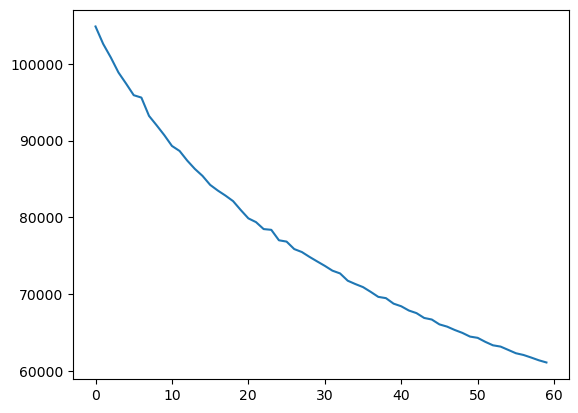

In [78]:
plt.plot(all_inertia)
plt.show()

In [73]:
len(all_inertia)

51

In [76]:
all_inertia

[10995307520.0,
 10524952576.0,
 10165864448.0,
 9775880192.0,
 9490916352.0,
 9199343616.0,
 9140021248.0,
 8690100224.0,
 8462023680.0,
 8228939264.0,
 7976027136.0,
 7859821568.0,
 7639264768.0,
 7450446848.0,
 7294794240.0,
 7096417280.0,
 6972768256.0,
 6863843328.0,
 6744842752.0,
 6556255744.0,
 6380988928.0,
 6303056896.0,
 6160229376.0,
 6144787968.0,
 5933367296.0,
 5906839040.0,
 5758628864.0,
 5699958272.0,
 5605015040.0,
 5517232640.0,
 5431875584.0,
 5339758592.0,
 5287086080.0,
 5150318592.0,
 5088082432.0,
 5031776768.0,
 4944872448.0,
 4852894208.0,
 4829822976.0,
 4730800128.0,
 4684065792.0,
 4608542720.0,
 4562649600.0,
 4478259712.0,
 4450795520.0,
 4366738432.0,
 4328500736.0,
 4271220224.0,
 4221741056.0,
 4159279104.0,
 4138446848.0,
 4071617536.0,
 4014354944.0,
 3993123840.0,
 3939003136.0,
 3884662784.0,
 3856388608.0,
 3815141888.0,
 3771306752.0,
 3736009216.0]